## WeatherAnalyze

## Importer

In [110]:
import requests
import json
import matplotlib.pyplot as plt

print("Nödvändiga importer laddade!")


Nödvändiga importer laddade!


In [111]:
# Dictionary med koordinater för städerna inför anrop till API

cities = {
    "Stockholm": [59.33, 18.07],
    "Göteborg": [57.71, 11.97],
    "Malmö": [55.61, 13.00]
}


print(f"Skriver ut testkoordinater för Sthlm: {cities["Stockholm"]}")

Skriver ut testkoordinater för Sthlm: [59.33, 18.07]


## Funktion för att ta emot användarens val av stad

In [112]:
def get_city():
    print("Välj stad för att hämta ett dygns väderprognos:")
    print("1. Stockholm")
    print("2. Göteborg")
    print("3. Malmö")

    while True:
        choice = input("Ange vilken stad du vill hämta prognosen ifrån (1-3):")
        
        if choice == "1":
            return "Stockholm"
        elif choice == "2":
            return "Göteborg"
        elif choice == "3":
            return "Malmö"
        else:
            print("Du måste välja en siffra (1-3)!")

    

## Funktion för att låta användaren välja om den vill visa mer information.

In [113]:
def get_detailed_info():
    extra_choice = input("Vill du visa detaljerad information om vind? (j/n): ")
    if extra_choice == "j":
        return True
    else:
        return False

## Funktion för att ta emot koordinaterna och använda dem i api-anropet

In [114]:
def get_weather(latitude, longitude):
    url = "https://api.open-meteo.com/v1/forecast"

    weather_parameters = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,wind_speed_10m",
        "forecast_days": 1
    }

    try:
        response = requests.get(url, params=weather_parameters)
        response.raise_for_status()
        data = response.json()
        
        temperature = data["hourly"]["temperature_2m"]
        weather_time = data["hourly"]["time"]
        wind = data["hourly"]["wind_speed_10m"]
    
        return temperature, weather_time, wind

    except requests.exceptions.RequestException:
        print("Kunde inte hämta väderdata från API.")
        return None, None, None
        
    



## Klasser och OOP

In [115]:
# Skapar en väder-klass

class Weather:
    def __init__(self, city, temperature, weather_time):
        self.city = city
        self.temperature = temperature
        self.time = weather_time

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}"

class DetailedWeather(Weather):
    def __init__(self, city, temperature, weather_time, wind):
        super().__init__(city, temperature, weather_time)
        self.wind = wind

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}, vindhastighet: {self.wind}."

## Kopplar ihop valet av stad med väderinfon som fås av API

In [116]:
weather_history = []

city = get_city()
detailed_info = get_detailed_info()

latitude, longitude = cities[city]

temperature, weather_time, wind = get_weather(latitude, longitude)

if temperature is not None:
    for i in range(len(weather_time)):
        if detailed_info:
            weather_object = DetailedWeather(
            city,
            temperature[i],
            weather_time[i],
            wind[i]
            )
        else:
            weather_object = Weather(
                city,
                temperature[i],
                weather_time[i]
            )
        weather_history.append(weather_object)

    for weather_object in weather_history:
        print(weather_object)



Välj stad för att hämta ett dygns väderprognos:
1. Stockholm
2. Göteborg
3. Malmö
Temperaturen i Malmö är 15.6°C, tidpunkt: 2026-09-30T00:00
Temperaturen i Malmö är 15.4°C, tidpunkt: 2026-09-30T01:00
Temperaturen i Malmö är 15.5°C, tidpunkt: 2026-09-30T02:00
Temperaturen i Malmö är 15.7°C, tidpunkt: 2026-09-30T03:00
Temperaturen i Malmö är 15.6°C, tidpunkt: 2026-09-30T04:00
Temperaturen i Malmö är 15.7°C, tidpunkt: 2026-09-30T05:00
Temperaturen i Malmö är 14.8°C, tidpunkt: 2026-09-30T06:00
Temperaturen i Malmö är 15.3°C, tidpunkt: 2026-09-30T07:00
Temperaturen i Malmö är 15.9°C, tidpunkt: 2026-09-30T08:00
Temperaturen i Malmö är 17.0°C, tidpunkt: 2026-09-30T09:00
Temperaturen i Malmö är 18.0°C, tidpunkt: 2026-09-30T10:00
Temperaturen i Malmö är 18.6°C, tidpunkt: 2026-09-30T11:00
Temperaturen i Malmö är 19.6°C, tidpunkt: 2026-09-30T12:00
Temperaturen i Malmö är 20.4°C, tidpunkt: 2026-09-30T13:00
Temperaturen i Malmö är 20.5°C, tidpunkt: 2026-09-30T14:00
Temperaturen i Malmö är 19.8°C, t

## Spara den hämtade datan

In [117]:
def save_weather(weather_history):
    weather_data = []

    for weather_object in weather_history:
        data = {
            "city": weather_object.city,
            "temperature": weather_object.temperature,
            "time": weather_object.time
        }

        if isinstance(weather_object, DetailedWeather):
            data["wind"] = weather_object.wind

        weather_data.append(data)

    try:
        with open("weather_data.json", "r", encoding="utf-8") as file:
            old_data = json.load(file)
    except FileNotFoundError:
        old_data = []

    old_data.extend(weather_data)

    with open("weather_data.json", "w", encoding="utf-8") as file:
        json.dump(old_data, file, indent=4, ensure_ascii=False)

if temperature is not None:
    save_weather(weather_history)
    print("Den hämtade datan har sparats i en JSON-filen!")


Den hämtade datan har sparats i en JSON-filen!


## Analys av väderdata

In [118]:
def analyze_temperature(temperature, city):
    min_temperature = min(temperature)
    max_temperature = max(temperature)
    avg_temperature = sum(temperature) / len(temperature)

    print(f"Kortfattad analys av prognosen för {city} det kommande dygnet: ")
    print(f"Lägsta temperatur: {min_temperature}°C")
    print(f"Högsta temperatur: {max_temperature}°C")
    print(f"Medeltemperatur: {avg_temperature:.1f}°C")

if temperature is not None:
    analyze_temperature(temperature, city)

Kortfattad analys av prognosen för Malmö det kommande dygnet: 
Lägsta temperatur: 14.7°C
Högsta temperatur: 20.5°C
Medeltemperatur: 16.7°C


## Funktion för att visa hur temperaturen ändras över tid

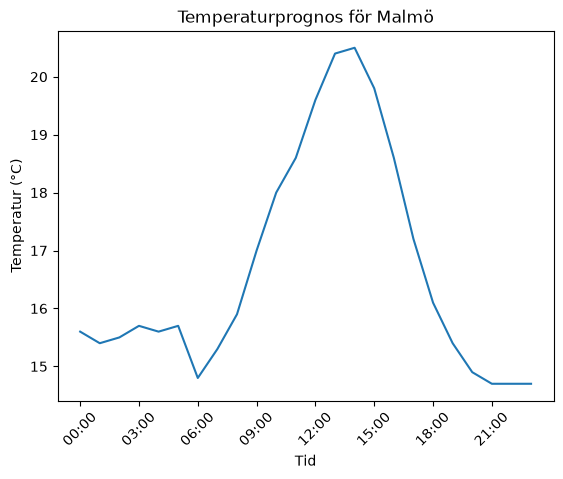

In [ ]:
def plot_temperature(weather_time, temperature, city):
    time_labels = []

    # Plockar ut klockslaget från varje värde i weather_time och sparar det i time_labels
    for time in weather_time:
        time_labels.append(time[11:16])

    plt.plot(time_labels, temperature)

    plt.xlabel("Tid")
    plt.ylabel("Temperatur (°C)")
    plt.title(f"Temperaturprognos för {city}")

    plt.xticks(time_labels[::3], rotation=45)
    plt.show()

if temperature is not None:
    plot_temperature(weather_time, temperature, city)